# Baseline — MFCC + Logistic Regression  

In [1]:
# =========================
# IMPORTS
# =========================
import os
import json
import numpy as np
import librosa
from pathlib import Path
from collections import Counter
from tqdm import tqdm

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix, f1_score

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# =========================
# CONFIG
# =========================
DATA_DIR = "./data"
SAVE_DIR = "./results"

SR         = 16000
DURATION   = 3
N_MFCC     = 40
N_FFT      = 2048
HOP_LENGTH = 306

os.makedirs(SAVE_DIR, exist_ok=True)

In [18]:
# =========================
# AUDIO UTILITIES
# =========================

def pad_audio(y, target_len):
    if len(y) >= target_len:
        return y[:target_len]
    pad_width = target_len - len(y)
    if pad_width > len(y):
        return np.pad(y, (0, pad_width), mode='edge')
    return np.pad(y, (0, pad_width), mode='reflect')

def preprocess_audio(file_path):
    try:
        y, _ = librosa.load(file_path, sr=SR)
    except Exception:
        return None
    if y is None or len(y) == 0:
        return None
    y, _ = librosa.effects.trim(y)
    if len(y) < SR * 0.5:
        return None
    if np.max(np.abs(y)) == 0:
        return None
    return y

def segment_audio(y, sr=SR, duration=DURATION):
    seg_len = int(sr * duration)
    hop_len = seg_len // 2        # 50% overlap
    if len(y) >= seg_len:
        return [y[s:s + seg_len] for s in range(0, len(y) - seg_len + 1, hop_len)]
    return [pad_audio(y, seg_len)]

def extract_mfcc_features(y, sr=SR, n_mfcc=N_MFCC):
    """
    Extract MFCC summary statistics across the time axis.
    Returns a 160-dim vector: [mean, std, max, min] for each of 40 MFCCs.

    This is the standard handcrafted baseline — collapses the 2D
    time-frequency structure that CNNs learn to exploit spatially.
    """
    mfcc = librosa.feature.mfcc(
        y=y, sr=sr, n_mfcc=n_mfcc,
        n_fft=N_FFT, hop_length=HOP_LENGTH
    )
    return np.concatenate([
        mfcc.mean(axis=1),
        mfcc.std(axis=1),
        mfcc.max(axis=1),
        mfcc.min(axis=1),
    ])

In [19]:
# =========================
# STEP 1 — FEATURE EXTRACTION
# =========================
wav_files = list(Path(DATA_DIR).rglob("*.wav"))
print(f"Found {len(wav_files)} wav files.")


unique_label_names = sorted(set(p.parent.name for p in wav_files))
label_to_idx = {name: i for i, name in enumerate(unique_label_names)}
idx_to_label = {i: name for name, i in label_to_idx.items()}
print("Label mapping:", label_to_idx)

X_list        = []   # feature vectors
y_list        = []
file_ids_list = []

failed = 0
for file_path in tqdm(wav_files, desc="Extracting features"):
    signal = preprocess_audio(str(file_path))
    if signal is None:
        failed += 1
        continue
    label_idx = label_to_idx[file_path.parent.name]
    for seg in segment_audio(signal):
        feat = extract_mfcc_features(seg)
        X_list.append(feat)
        y_list.append(label_idx)
        file_ids_list.append(str(file_path))

X        = np.array(X_list,        dtype=np.float32)
y        = np.array(y_list,        dtype=np.int32)
file_ids = np.array(file_ids_list, dtype=object)

print(f"\nExtracted {len(X)} segments from {len(wav_files) - failed} files ({failed} failed).")
print(f"Feature vector shape: {X.shape}")
print("Class counts:", {idx_to_label[k]: v for k, v in Counter(y.tolist()).items()})

Found 1691 wav files.
Label mapping: {'cargo_ship': 0, 'passenger_ship': 1, 'speed_boat': 2, 'tanker': 3, 'uuv': 4}


Extracting features: 100%|██████████| 1691/1691 [11:23<00:00,  2.47it/s]


Extracted 55924 segments from 1691 files (0 failed).
Feature vector shape: (55924, 160)
Class counts: {'speed_boat': 470, 'uuv': 902, 'cargo_ship': 25521, 'passenger_ship': 28010, 'tanker': 1021}


In [20]:
# =========================
# STEP 2 — FILE-LEVEL STRATIFIED SPLIT
#   70% train / 15% val / 15% test
# =========================
unique_files  = np.unique(file_ids)
unique_labels = np.array([y[file_ids == f][0] for f in unique_files])

print("File-level class counts:",
      {idx_to_label[k]: v for k, v in Counter(unique_labels.tolist()).items()})

sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, temp_idx = next(sss1.split(unique_files, unique_labels))
train_files = unique_files[train_idx]
temp_files  = unique_files[temp_idx]
temp_labels = unique_labels[temp_idx]

temp_label_counts  = Counter(temp_labels)
can_stratify_split = all(c >= 2 for c in temp_label_counts.values())

if can_stratify_split:
    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
    val_idx, test_idx = next(sss2.split(temp_files, temp_labels))
else:
    from sklearn.model_selection import ShuffleSplit
    print("WARNING: falling back to random split (rare class < 2 files in temp)")
    val_idx, test_idx = next(
        ShuffleSplit(n_splits=1, test_size=0.5, random_state=42).split(temp_files)
    )

val_files  = temp_files[val_idx]
test_files = temp_files[test_idx]

train_mask = np.isin(file_ids, train_files)
val_mask   = np.isin(file_ids, val_files)
test_mask  = np.isin(file_ids, test_files)

X_train, y_train = X[train_mask], y[train_mask]
X_val,   y_val   = X[val_mask],   y[val_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

print(f"\nTrain segs: {train_mask.sum()} | Val segs: {val_mask.sum()} | Test segs: {test_mask.sum()}")
for split_name, y_split in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    counts = Counter(y_split.tolist())
    total  = len(y_split)
    dist   = {idx_to_label[k]: f"{v} ({100*v/total:.1f}%)" for k, v in sorted(counts.items())}
    print(f"  {split_name:5s}: {dist}")

File-level class counts: {'cargo_ship': 109, 'passenger_ship': 184, 'speed_boat': 470, 'tanker': 26, 'uuv': 902}

Train segs: 40514 | Val segs: 8289 | Test segs: 7121
  Train: {'cargo_ship': '18932 (46.7%)', 'passenger_ship': '19997 (49.4%)', 'speed_boat': '329 (0.8%)', 'tanker': '625 (1.5%)', 'uuv': '631 (1.6%)'}
  Val  : {'cargo_ship': '2992 (36.1%)', 'passenger_ship': '4850 (58.5%)', 'speed_boat': '70 (0.8%)', 'tanker': '241 (2.9%)', 'uuv': '136 (1.6%)'}
  Test : {'cargo_ship': '3597 (50.5%)', 'passenger_ship': '3163 (44.4%)', 'speed_boat': '71 (1.0%)', 'tanker': '155 (2.2%)', 'uuv': '135 (1.9%)'}


In [21]:
# =========================
# STEP 3 — STANDARDIZE FEATURES
# =========================
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print(f"After scaling — Train mean: {X_train.mean():.4f}  std: {X_train.std():.4f}")
print(f"               Val   mean: {X_val.mean():.4f}  std: {X_val.std():.4f}")

After scaling — Train mean: 0.0000  std: 1.0000
               Val   mean: -0.0027  std: 1.0488


In [22]:
# =========================
# STEP 4 — TRAIN LOGISTIC REGRESSION
# =========================
clf = LogisticRegression(
    class_weight = 'balanced',
    max_iter     = 1000,
    C            = 1.0,
    solver       = 'lbfgs',
    multi_class  = 'multinomial',
    random_state = 42,
    n_jobs       = -1,
)

print("Training Logistic Regression...")
clf.fit(X_train, y_train)
print("Done.")

val_preds = clf.predict(X_val)
val_f1    = f1_score(y_val, val_preds, average='macro')
print(f"Val Macro F1: {val_f1:.4f}")

Training Logistic Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Done.
Val Macro F1: 0.6134



===== BASELINE TEST SET RESULTS =====
                precision    recall  f1-score   support

    cargo_ship       0.83      0.70      0.76      3597
passenger_ship       0.72      0.69      0.71      3163
    speed_boat       0.83      0.94      0.88        71
        tanker       0.05      0.28      0.09       155
           uuv       0.96      0.95      0.96       135

      accuracy                           0.70      7121
     macro avg       0.68      0.71      0.68      7121
  weighted avg       0.77      0.70      0.73      7121



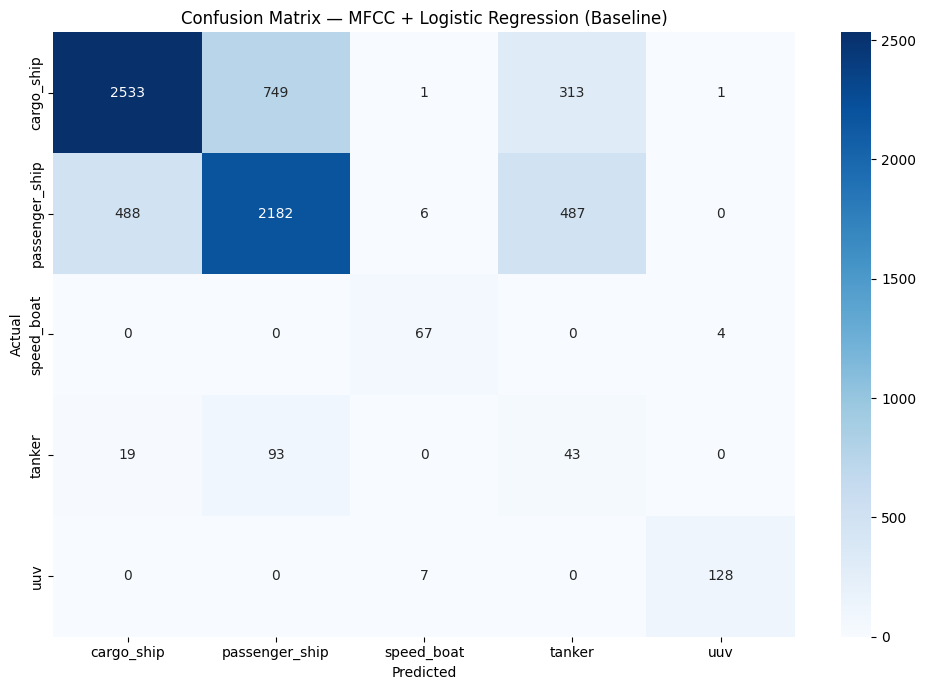

In [23]:
# =========================
# STEP 5 — TEST SET EVALUATION
# =========================
test_preds  = clf.predict(X_test)
target_names = [idx_to_label[i] for i in sorted(idx_to_label.keys())]

print("\n===== BASELINE TEST SET RESULTS =====")
print(classification_report(y_test, test_preds, target_names=target_names))

cm = confusion_matrix(y_test, test_preds)
plt.figure(figsize=(10, 7))
sns.heatmap(
    cm, annot=True, fmt='d',
    xticklabels=target_names,
    yticklabels=target_names,
    cmap='Blues'
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — MFCC + Logistic Regression (Baseline)')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "cm_baseline_mfcc_lr.png"), dpi=150)
plt.show()

In [ ]:
# =========================
# STEP 6 — SAVE RESULTS TO DRIVE
# =========================
results = {
    "model"          : "MFCC + Logistic Regression",
    "n_mfcc"         : N_MFCC,
    "feature_dim"    : X_train.shape[1],
    "segment_duration": DURATION,
    "split"          : "70/15/15 file-level stratified",
    "val_macro_f1"   : round(float(val_f1), 4),
    "test_macro_f1"  : round(float(f1_score(y_test, test_preds, average='macro')), 4),
    "test_report"    : classification_report(
                            y_test, test_preds,
                            target_names=target_names,
                            output_dict=True
                       )
}

results_path = os.path.join(SAVE_DIR, "baseline_mfcc_lr_results.json")
with open(results_path, "w") as f:
    json.dump(results, f, indent=2)
print(f"Results saved to Drive: {results_path}")
print(f"\nTest Macro F1 : {results['test_macro_f1']}")
print(f"Val  Macro F1 : {results['val_macro_f1']}")